Customer Segmentation

#### Objective

The goal of this notebook is to identify different customer groups based on their purchasing behavior using RFM (Recency, Frequency, Monetary) analysis and clustering techniques.

This analysis will help the business understand which customers are the most valuable and which customers require retention strategies.

In [1]:
import pandas as pd 

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/ecommerce_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [3]:
df['Customer_ID'].nunique()

5000

In [4]:
frequency = df.groupby('Customer_ID')['Order_ID'].nunique().reset_index(name='Frequency')

In [5]:
frequency.head()

,Customer_ID,Frequency
0,CUST_00001,3
1,CUST_00002,2
2,CUST_00003,2
3,CUST_00004,1
4,CUST_00005,3


In [6]:
monetary = df.groupby('Customer_ID')['Total_Amount'].sum().reset_index(name='Monetary')

In [7]:
monetary.head()

,Customer_ID,Monetary
0,CUST_00001,2199.63
1,CUST_00002,809.90
2,CUST_00003,3030.81
3,CUST_00004,383.22
4,CUST_00005,2422.73


In [8]:
customer_df = frequency.merge(monetary, on='Customer_ID', how='inner')

In [9]:
customer_df.head()


,Customer_ID,Frequency,Monetary
0,CUST_00001,3,2199.63
1,CUST_00002,2,809.90
2,CUST_00003,2,3030.81
3,CUST_00004,1,383.22
4,CUST_00005,3,2422.73


In [10]:
customer_df.shape

(5000, 3)

In [11]:
df['Date'].max()

Timestamp('2024-03-25 00:00:00')

In [12]:
snapshot_date = df['Date'].max() + pd.Timedelta(days=1)

In [13]:
last_purchase = df.groupby('Customer_ID')['Date'].max().reset_index(name='Last_Purchase_Date')

In [14]:
(snapshot_date - last_purchase['Last_Purchase_Date']).dt.days

0       112
1       284
2        83
3        42
4       279
       ... 
4995     33
4996    150
4997    334
4998     70
4999     67
Name: Last_Purchase_Date, Length: 5000, dtype: int64

In [15]:
last_purchase['Recency'] = (
    snapshot_date - last_purchase['Last_Purchase_Date']
).dt.days

In [16]:
last_purchase.head()

,Customer_ID,Last_Purchase_Date,Recency
0,CUST_00001,2023-12-05,112
1,CUST_00002,2023-06-16,284
2,CUST_00003,2024-01-03,83
3,CUST_00004,2024-02-13,42
4,CUST_00005,2023-06-21,279


In [17]:
customer_rfm = frequency.merge(monetary.merge(last_purchase[['Customer_ID','Recency']],  on='Customer_ID', how='inner'))

In [18]:
customer_rfm.head()

,Customer_ID,Frequency,Monetary,Recency
0,CUST_00001,3,2199.63,112
1,CUST_00002,2,809.90,284
2,CUST_00003,2,3030.81,83
3,CUST_00004,1,383.22,42
4,CUST_00005,3,2422.73,279


In [19]:
monetary.head()

,Customer_ID,Monetary
0,CUST_00001,2199.63
1,CUST_00002,809.90
2,CUST_00003,3030.81
3,CUST_00004,383.22
4,CUST_00005,2422.73


### Building Customer-Level RFM Dataset

#### Objective
Transform transaction-level data into customer-level metrics for segmentation.

#### Metrics Created

- Recency: Number of days since the customer's last purchase.
- Frequency: Total number of orders placed by the customer.
- Monetary: Total revenue generated by the customer.

#### Result
A customer-level dataset containing 5,000 unique customers was created.

#### Business Value
The RFM dataset enables customer segmentation, customer value analysis, retention strategy development, and targeted marketing campaigns.

In [20]:
customer_rfm.describe()

,Frequency,Monetary,Recency
count,5000.000000,5000.000000,5000.000000
mean,3.409800,4355.810518,125.716400
std,2.181746,5274.546636,108.050972
min,1.000000,14.280000,1.000000
25%,2.000000,889.410000,39.000000
50%,3.000000,2493.925000,94.000000
75%,5.000000,5796.297500,185.000000
max,10.000000,50628.150000,450.000000


### RFM Summary Statistics

#### Frequency
- Average customer placed 3.4 orders.
- Most customers placed between 2 and 5 orders.
- Maximum observed frequency was 10 orders.

#### Monetary
- Average customer spending was 4,355.
- Median spending was 2,494.
- Large gap between mean and median indicates the presence of high-value customers.

#### Recency
- Average recency was 126 days.
- Some customers purchased very recently, while others have been inactive for over 450 days.

#### Key Insight
Customer value distribution is highly uneven. A relatively small group of customers appears to generate a disproportionately large share of total revenue.

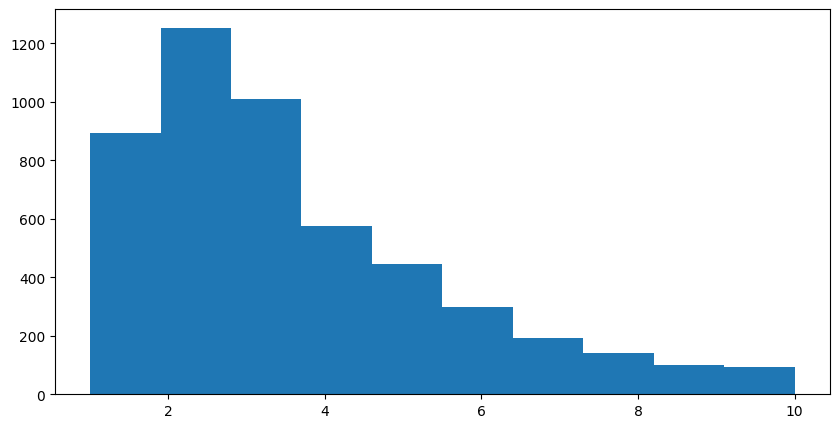

In [21]:
plt.figure(figsize=(10,5))


plt.hist(customer_rfm['Frequency'])
plt.show()

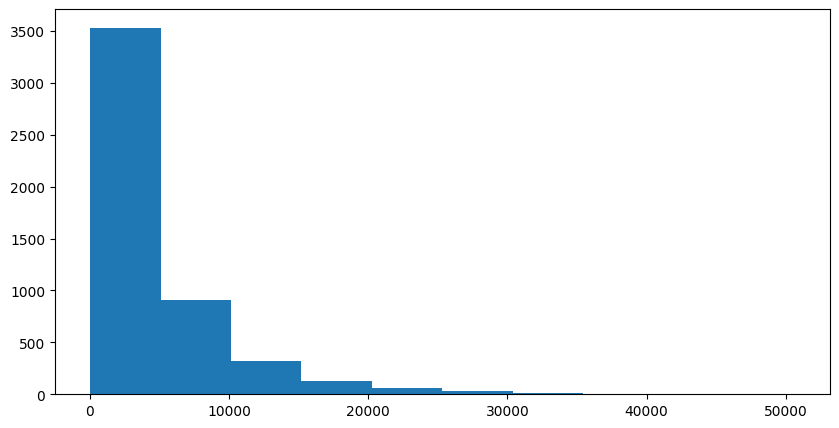

In [22]:
plt.figure(figsize=(10,5))


plt.hist(customer_rfm['Monetary'])
plt.show()

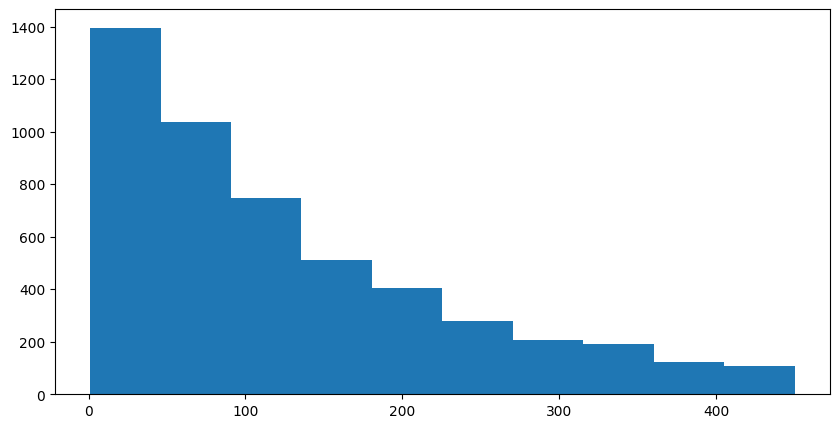

In [23]:
plt.figure(figsize=(10,5))


plt.hist(customer_rfm['Recency'])
plt.show()

### Distribution Analysis

#### Frequency
Frequency distribution is positively skewed, indicating that most customers place a small number of orders while a smaller group purchases more frequently.

#### Monetary
Monetary value shows strong positive skewness. A small number of customers contribute disproportionately high revenue, suggesting the presence of high-value customer segments.

#### Recency
Recency is positively skewed, indicating a mix of recently active customers and long-inactive customers.

#### Key Business Insight
Customer behavior is highly heterogeneous. The business appears to rely on a relatively small segment of high-value customers who generate a significant share of total revenue.

In [24]:
# Pareto Analysis
customer_rfm['Monetary'].sum()

np.float64(21779052.589999996)

In [25]:
pareto_df = customer_rfm.sort_values(
    by='Monetary',
    ascending=False
)

In [26]:
pareto_df.head()

,Customer_ID,Frequency,Monetary,Recency
1572,CUST_01573,2,50628.15,3
196,CUST_00197,10,47324.23,73
3794,CUST_03795,3,42480.02,48
153,CUST_00154,10,41613.83,31
4218,CUST_04219,8,40608.39,46


In [27]:
pareto_df['Cumulative_Revenue'] = pareto_df['Monetary'].cumsum()

In [28]:
pareto_df['Revenue_Percentage'] = (
    pareto_df['Cumulative_Revenue']
    / pareto_df['Monetary'].sum()
) * 100

In [29]:
top_20_percent = pareto_df.head(1000)

In [30]:
percentage = (
    top_20_percent['Monetary'].sum()
    / customer_rfm['Monetary'].sum()
) * 100

print(percentage)

58.58328523371274


### Pareto Analysis

#### Objective
Determine whether revenue is concentrated among a small group of customers.
#### Finding
The top 20% of customers generate approximately 58.6% of total revenue.
#### Key Insight
Revenue is not evenly distributed across customers. A relatively small segment of customers contributes the majority of business revenue.
#### Business Recommendation
Prioritize retention strategies, loyalty programs, and personalized marketing campaigns for high-value customers.

In [31]:
customer_rfm[['Recency','Frequency','Monetary']].quantile([0.2,0.4,0.6,0.8])

,Recency,Frequency,Monetary
0.2,30.0,2.0,659.676
0.4,71.0,2.0,1703.092
0.6,123.0,3.0,3529.312
0.8,212.0,5.0,6892.678


In [32]:
customer_rfm['M_Score'] = pd.qcut(
    customer_rfm['Monetary'],
    q=5,
    labels=[1,2,3,4,5]
)

In [33]:
customer_rfm['M_Score'].value_counts()

M_Score
1    1000
2    1000
3    1000
4    1000
5    1000
Name: count, dtype: int64

In [34]:
customer_rfm['R_Score'] = pd.qcut(
    customer_rfm['Recency'],
    q=5,
    labels=[5,4,3,2,1]
)

In [35]:
customer_rfm['R_Score'].value_counts()

R_Score
4    1027
5    1005
1     999
2     997
3     972
Name: count, dtype: int64

In [36]:
customer_rfm['Frequency'].value_counts().sort_index()

Frequency
1      892
2     1254
3     1009
4      575
5      445
6      299
7      192
8      141
9       99
10      94
Name: count, dtype: int64

In [37]:
customer_rfm['Frequency_Rank'] = customer_rfm['Frequency'].rank(method='first')

In [38]:
customer_rfm['F_Score'] = pd.qcut(
    customer_rfm['Frequency_Rank'],
    q=5,
    labels=[1,2,3,4,5]
)

In [39]:
customer_rfm['F_Score'].value_counts()

F_Score
1    1000
2    1000
3    1000
4    1000
5    1000
Name: count, dtype: int64

RFM Score

In [40]:
customer_rfm[['R_Score','F_Score','M_Score']].dtypes

R_Score    category
F_Score    category
M_Score    category
dtype: object

In [41]:
customer_rfm['R_Score'] = customer_rfm['R_Score'].astype(int)
customer_rfm['F_Score'] = customer_rfm['F_Score'].astype(int)
customer_rfm['M_Score'] = customer_rfm['M_Score'].astype(int)

In [42]:
customer_rfm['RFM_Score'] = (
    customer_rfm['R_Score']
    + customer_rfm['F_Score']
    + customer_rfm['M_Score']
)

In [43]:
customer_rfm['RFM_Code'] = (
    customer_rfm['R_Score'].astype(str)
    + customer_rfm['F_Score'].astype(str)
    + customer_rfm['M_Score'].astype(str)
)

In [44]:
customer_rfm[['RFM_Score']].describe()

,RFM_Score
count,5000.000000
mean,9.008400
std,3.392968
min,3.000000
25%,6.000000
50%,9.000000
75%,12.000000
max,15.000000


In [45]:
customer_rfm['RFM_Code'].value_counts().head(10)

RFM_Code
111    292
555    226
455    149
554    115
211    114
355     95
454     94
122     94
444     85
311     85
Name: count, dtype: int64

In [46]:
customer_rfm.to_csv('../data/processed/customer_rfm.csv', index=False)